In [69]:
from datascience import *
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

In [70]:
sf = Table.read_table("san_francisco_2019.csv")
sf.show(3)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468


In [71]:
min_salary = 15*20*50
sf = sf.where("Salary", are.above(min_salary))
sf.num_rows

37103

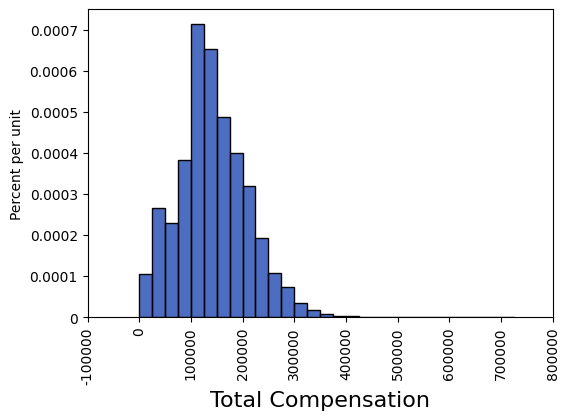

In [72]:
sf_bins = np.arange(0, 726000, 25000)
sf.hist("Total Compensation", bins=sf_bins)

In [73]:
def median_comp(t):
    return percentile(50, t.column("Total Compensation"))

median_comp(sf)

135747.0

In [74]:
sample_size = 100
our_sample = sf.sample(sample_size,  with_replacement=False)

In [75]:
def confidence_interval_95(sample_size):
    # Collect one random sample from the population
    our_sample = sf.sample(sample_size, with_replacement=False)
    median_comp(our_sample)

    # Generate the medians of 1000 bootstrap samples
    num_repetitions = 1000
    bstrap_medians = make_array()
    for i in np.arange(num_repetitions):
        # Resample the same number of rows, with replacement
        bstrap_medians = np.append(bstrap_medians, 
                                   median_comp(our_sample.sample()))

    # Find the middle 95% of medians; that's a confidence interval
    left = percentile(2.5, bstrap_medians)
    right = percentile(97.5, bstrap_medians)
    return make_array(left, right)

confidence_interval_95(100)

array([ 139752.,  169494.])

In [76]:
intervals = Table(['k', 'lower', 'upper', 'sample_size'])

for n in [200, 400]:
    for k in np.arange(intervals.num_rows, intervals.num_rows + 20):
        interval = confidence_interval_95(n)
        intervals = intervals.with_row([
            k, interval.item(0), interval.item(1), n
        ])
    
intervals.show(4)

k,lower,upper,sample_size
0,126807,150735,200
1,126068,151937,200
2,126657,146823,200
3,124962,138630,200


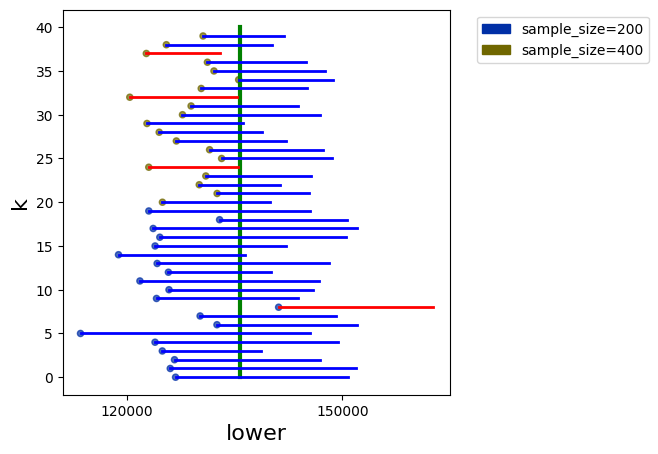

In [77]:
intervals.scatter('lower', 'k', group='sample_size')
truth = median_comp(sf)
plt.plot((truth, truth), (0, intervals.num_rows), color='green', lw=3)
plt.xticks([120000, 150000])
for row in intervals.rows:
    if row.item('lower') > truth or row.item('upper') < truth:
        color = 'red'
    else:
        color = 'blue'
    plt.plot((row.item('lower'), row.item('upper')),
               (row.item('k'), row.item('k')),
               color, lw=2)


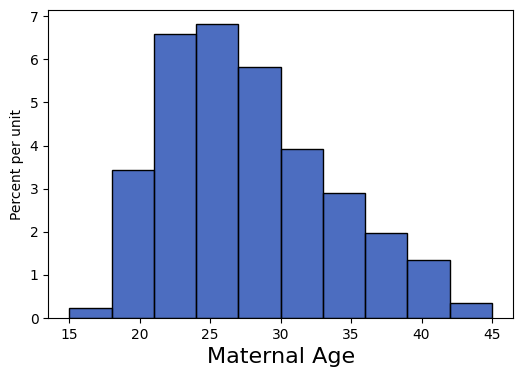

In [78]:
births = Table.read_table("baby.csv")
births.hist("Maternal Age")

In [79]:
np.mean(births.column("Maternal Age"))

27.228279386712096

In [80]:
def one_bootstrap_mean():
    resample = births.sample()
    return np.average(resample.column("Maternal Age"))

In [81]:
num_reps = 3000
btstrap_means = make_array()

for i in range(num_reps):
    btstrap_means = np.append(btstrap_means, one_bootstrap_mean())

In [82]:
left = percentile(2.5, btstrap_means)
right = percentile(97.5, btstrap_means)
make_array(left, right)

array([ 26.88841567,  27.56473595])

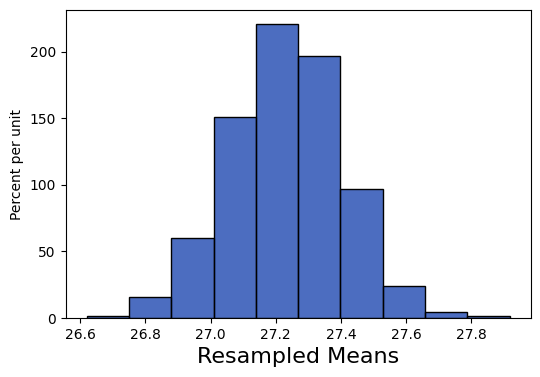

In [83]:
resample_means = Table().with_column("Resampled Means", btstrap_means).hist()